# Training Performance Evaluation: E1-no vs E1-augmentation

This notebook compares the performance of two U-Net segmentation models:
- **E1-no**: Baseline model without data augmentation
- **E1-augmentation**: Model with data augmentation

## Evaluation Metrics:
1. **Training Performance**: Convergence, time, efficiency, emissions
2. **Inference Performance**: Speed, throughput, emissions
3. **Model Performance**: Accuracy, Dice Score, IoU, per-class metrics


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')
sns.set_palette("husl")

# Paths
E1_NO_PATH = Path("../../E1-no/training_reports")
E1_AUG_PATH = Path("../../E1-augmentation/training_reports")

print("Loading training reports...")


Loading training reports...


In [2]:
# Load training efficiency data
e1_no_eff = pd.read_csv(E1_NO_PATH / "training_efficiency.csv")
e1_aug_eff = pd.read_csv(E1_AUG_PATH / "training_efficiency.csv")

# Load convergence data
e1_no_conv = pd.read_csv(E1_NO_PATH / "convergence.csv")
e1_aug_conv = pd.read_csv(E1_AUG_PATH / "convergence.csv")

# Load inference data
e1_no_inf = pd.read_csv(E1_NO_PATH / "inference.csv")
e1_aug_inf = pd.read_csv(E1_AUG_PATH / "inference.csv")

# Load inference emissions
e1_no_inf_em = pd.read_csv(E1_NO_PATH / "inference_emissions.csv")
e1_aug_inf_em = pd.read_csv(E1_AUG_PATH / "inference_emissions.csv")

print("Data loaded successfully!")
print(f"\nE1-no training runs: {len(e1_no_eff)}")
print(f"E1-augmentation training runs: {len(e1_aug_eff)}")


Data loaded successfully!

E1-no training runs: 4
E1-augmentation training runs: 3


## 1. Training Performance Analysis


In [3]:
# Calculate statistics for training efficiency
def calc_stats(df, name):
    stats = {
        'name': name,
        'mean_time_hours': df['Total Training Time (hours)'].mean(),
        'std_time_hours': df['Total Training Time (hours)'].std(),
        'mean_epoch_time': df['Average Epoch Time(s)'].mean(),
        'std_epoch_time': df['Average Epoch Time(s)'].std(),
        'mean_ram': df['Average RAM (GB)'].mean(),
        'mean_gpu_mem': df['Average GPU Memory (GB)'].mean(),
        'mean_co2': df['CO2 Emissions (kg)'].mean() if 'CO2 Emissions (kg)' in df.columns else None,
        'std_co2': df['CO2 Emissions (kg)'].std() if 'CO2 Emissions (kg)' in df.columns else None,
    }
    return stats

e1_no_stats = calc_stats(e1_no_eff, 'E1-no')
e1_aug_stats = calc_stats(e1_aug_eff, 'E1-augmentation')

# Create comparison dataframe
comparison_df = pd.DataFrame([e1_no_stats, e1_aug_stats])
print("Training Performance Comparison:")
print("=" * 80)
print(comparison_df.to_string(index=False))


Training Performance Comparison:
           name  mean_time_hours  std_time_hours  mean_epoch_time  std_epoch_time  mean_ram  mean_gpu_mem  mean_co2  std_co2
          E1-no         15.50781        0.873152      2791.405846      157.167304  1.223423      0.372873  1.387062 0.061143
E1-augmentation         16.34729        0.350442      2942.512117       63.079593  1.245279      0.372912  1.448586 0.021462


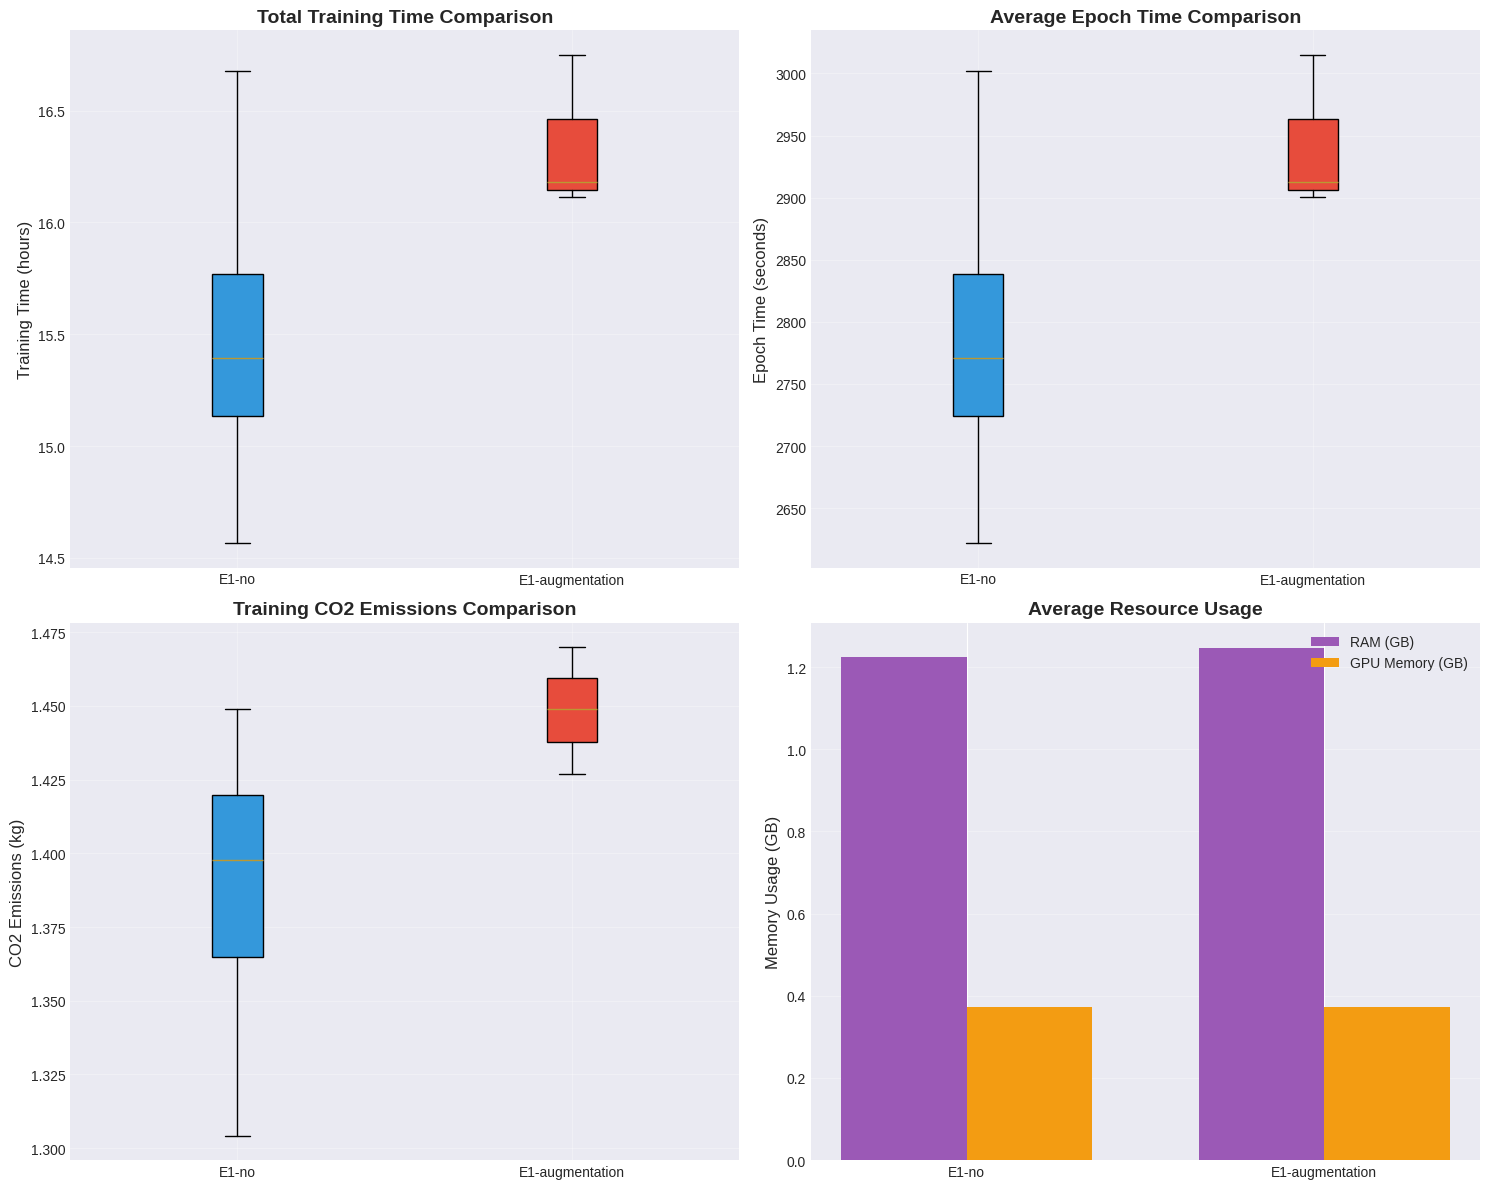

In [4]:
# Visualization: Training Time Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Total Training Time
ax1 = axes[0, 0]
data_time = [
    e1_no_eff['Total Training Time (hours)'].values,
    e1_aug_eff['Total Training Time (hours)'].values
]
bp1 = ax1.boxplot(data_time, labels=['E1-no', 'E1-augmentation'], patch_artist=True)
bp1['boxes'][0].set_facecolor('#3498db')
bp1['boxes'][1].set_facecolor('#e74c3c')
ax1.set_ylabel('Training Time (hours)', fontsize=12)
ax1.set_title('Total Training Time Comparison', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Average Epoch Time
ax2 = axes[0, 1]
data_epoch = [
    e1_no_eff['Average Epoch Time(s)'].values,
    e1_aug_eff['Average Epoch Time(s)'].values
]
bp2 = ax2.boxplot(data_epoch, labels=['E1-no', 'E1-augmentation'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#3498db')
bp2['boxes'][1].set_facecolor('#e74c3c')
ax2.set_ylabel('Epoch Time (seconds)', fontsize=12)
ax2.set_title('Average Epoch Time Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. CO2 Emissions
ax3 = axes[1, 0]
if 'CO2 Emissions (kg)' in e1_no_eff.columns and 'CO2 Emissions (kg)' in e1_aug_eff.columns:
    data_co2 = [
        e1_no_eff['CO2 Emissions (kg)'].values,
        e1_aug_eff['CO2 Emissions (kg)'].values
    ]
    bp3 = ax3.boxplot(data_co2, labels=['E1-no', 'E1-augmentation'], patch_artist=True)
    bp3['boxes'][0].set_facecolor('#3498db')
    bp3['boxes'][1].set_facecolor('#e74c3c')
    ax3.set_ylabel('CO2 Emissions (kg)', fontsize=12)
    ax3.set_title('Training CO2 Emissions Comparison', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)

# 4. Resource Usage
ax4 = axes[1, 1]
ram_data = [e1_no_eff['Average RAM (GB)'].mean(), e1_aug_eff['Average RAM (GB)'].mean()]
gpu_data = [e1_no_eff['Average GPU Memory (GB)'].mean(), e1_aug_eff['Average GPU Memory (GB)'].mean()]

x = np.arange(2)
width = 0.35
ax4.bar(x - width/2, ram_data, width, label='RAM (GB)', color='#9b59b6')
ax4.bar(x + width/2, gpu_data, width, label='GPU Memory (GB)', color='#f39c12')
ax4.set_ylabel('Memory Usage (GB)', fontsize=12)
ax4.set_title('Average Resource Usage', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['E1-no', 'E1-augmentation'])
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('training_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


Convergence Analysis:

E1-no Convergence Epochs:
  Mean: 18.0
  Std:  0.8
  Min:  17
  Max:  19

E1-augmentation Convergence Epochs:
  Mean: 13.0
  Std:  nan
  Min:  13
  Max:  13


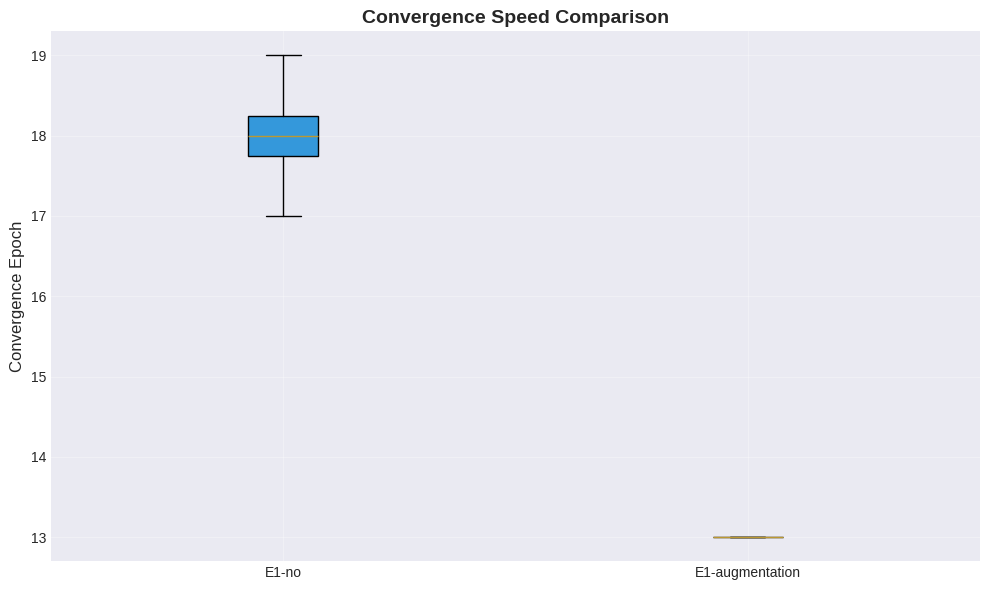

In [5]:
# Convergence Analysis
print("Convergence Analysis:")
print("=" * 80)
print(f"\nE1-no Convergence Epochs:")
print(f"  Mean: {e1_no_conv['Convergence Epoch'].mean():.1f}")
print(f"  Std:  {e1_no_conv['Convergence Epoch'].std():.1f}")
print(f"  Min:  {e1_no_conv['Convergence Epoch'].min():.0f}")
print(f"  Max:  {e1_no_conv['Convergence Epoch'].max():.0f}")

print(f"\nE1-augmentation Convergence Epochs:")
print(f"  Mean: {e1_aug_conv['Convergence Epoch'].mean():.1f}")
print(f"  Std:  {e1_aug_conv['Convergence Epoch'].std():.1f}")
print(f"  Min:  {e1_aug_conv['Convergence Epoch'].min():.0f}")
print(f"  Max:  {e1_aug_conv['Convergence Epoch'].max():.0f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
conv_data = [
    e1_no_conv['Convergence Epoch'].values,
    e1_aug_conv['Convergence Epoch'].values
]
bp = ax.boxplot(conv_data, labels=['E1-no', 'E1-augmentation'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_ylabel('Convergence Epoch', fontsize=12)
ax.set_title('Convergence Speed Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Inference Performance Analysis


In [6]:
# Inference performance comparison
print("Inference Performance Comparison:")
print("=" * 80)

inf_comparison = pd.DataFrame({
    'Metric': ['Total Time (hours)', 'Total Time (seconds)', 'Avg GPU Memory (GB)', 
               'CO2 Emissions (kg)', 'Accuracy', 'Dice Score', 'IoU'],
    'E1-no (Mean)': [
        e1_no_inf['Total Inference Time (hours)'].mean(),
        e1_no_inf['Total Inference Time (second)'].mean(),
        e1_no_inf['Average GPU Memory (GB)'].mean(),
        e1_no_inf['CO2 Emissions (kg)'].mean(),
        e1_no_inf['Accuracy'].mean(),
        e1_no_inf['Dice Score'].mean(),
        e1_no_inf['IoU'].mean()
    ],
    'E1-no (Std)': [
        e1_no_inf['Total Inference Time (hours)'].std(),
        e1_no_inf['Total Inference Time (second)'].std(),
        e1_no_inf['Average GPU Memory (GB)'].std(),
        e1_no_inf['CO2 Emissions (kg)'].std(),
        e1_no_inf['Accuracy'].std(),
        e1_no_inf['Dice Score'].std(),
        e1_no_inf['IoU'].std()
    ],
    'E1-aug (Mean)': [
        e1_aug_inf['Total Inference Time (hours)'].mean(),
        e1_aug_inf['Total Inference Time (second)'].mean(),
        e1_aug_inf['Average GPU Memory (GB)'].mean(),
        e1_aug_inf['CO2 Emissions (kg)'].mean(),
        e1_aug_inf['Accuracy'].mean(),
        e1_aug_inf['Dice Score'].mean(),
        e1_aug_inf['IoU'].mean()
    ],
    'E1-aug (Std)': [
        e1_aug_inf['Total Inference Time (hours)'].std(),
        e1_aug_inf['Total Inference Time (second)'].std(),
        e1_aug_inf['Average GPU Memory (GB)'].std(),
        e1_aug_inf['CO2 Emissions (kg)'].std(),
        e1_aug_inf['Accuracy'].std(),
        e1_aug_inf['Dice Score'].std(),
        e1_aug_inf['IoU'].std()
    ]
})

print(inf_comparison.to_string(index=False))


Inference Performance Comparison:
              Metric  E1-no (Mean)  E1-no (Std)  E1-aug (Mean)  E1-aug (Std)
  Total Time (hours)      0.607524     0.010730       0.620114      0.011905
Total Time (seconds)   2187.086774    38.629431    2232.409977     42.857948
 Avg GPU Memory (GB)      0.963761     0.000000       0.963761      0.000000
  CO2 Emissions (kg)      0.046405     0.001244       0.047236      0.001743
            Accuracy      0.994109     0.000555       0.993226      0.000243
          Dice Score      0.227654     0.004290       0.226001      0.002562
                 IoU      0.216769     0.004330       0.214093      0.002387


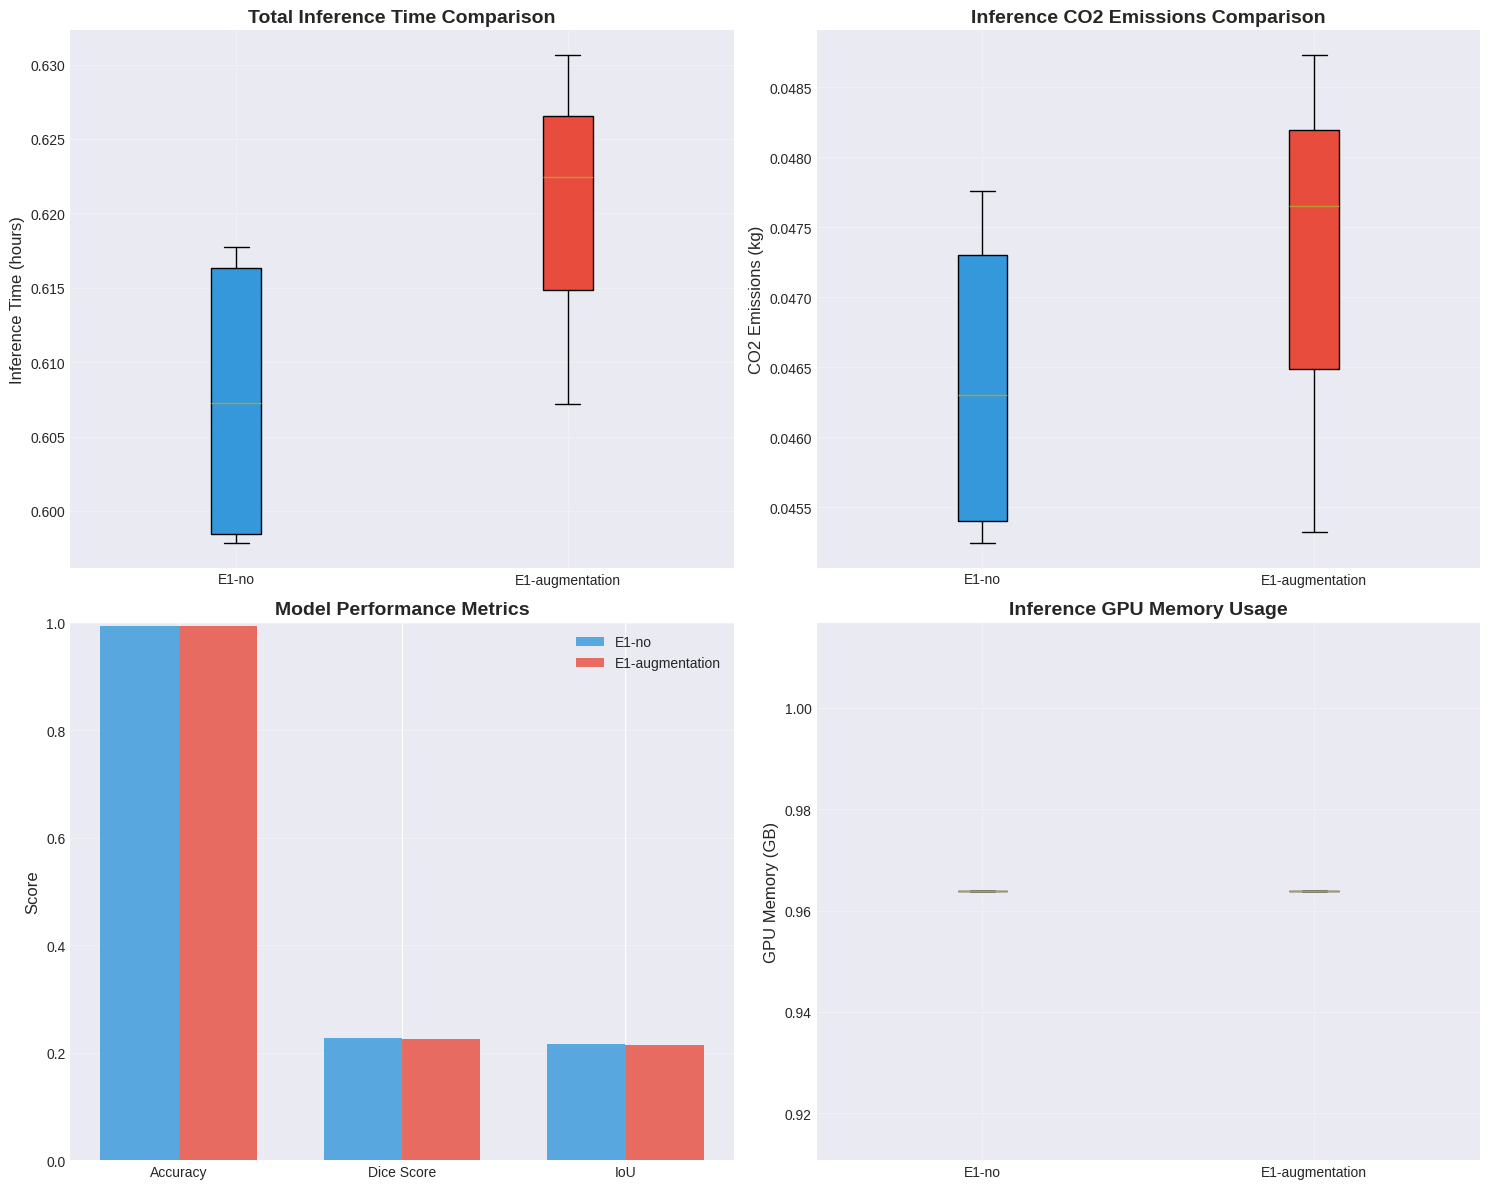

In [7]:
# Visualization: Inference Performance
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Inference Time
ax1 = axes[0, 0]
data_inf_time = [
    e1_no_inf['Total Inference Time (hours)'].values,
    e1_aug_inf['Total Inference Time (hours)'].values
]
bp1 = ax1.boxplot(data_inf_time, labels=['E1-no', 'E1-augmentation'], patch_artist=True)
bp1['boxes'][0].set_facecolor('#3498db')
bp1['boxes'][1].set_facecolor('#e74c3c')
ax1.set_ylabel('Inference Time (hours)', fontsize=12)
ax1.set_title('Total Inference Time Comparison', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. CO2 Emissions (Inference)
ax2 = axes[0, 1]
data_inf_co2 = [
    e1_no_inf['CO2 Emissions (kg)'].values,
    e1_aug_inf['CO2 Emissions (kg)'].values
]
bp2 = ax2.boxplot(data_inf_co2, labels=['E1-no', 'E1-augmentation'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#3498db')
bp2['boxes'][1].set_facecolor('#e74c3c')
ax2.set_ylabel('CO2 Emissions (kg)', fontsize=12)
ax2.set_title('Inference CO2 Emissions Comparison', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Model Performance Metrics
ax3 = axes[1, 0]
metrics = ['Accuracy', 'Dice Score', 'IoU']
e1_no_metrics = [
    e1_no_inf['Accuracy'].mean(),
    e1_no_inf['Dice Score'].mean(),
    e1_no_inf['IoU'].mean()
]
e1_aug_metrics = [
    e1_aug_inf['Accuracy'].mean(),
    e1_aug_inf['Dice Score'].mean(),
    e1_aug_inf['IoU'].mean()
]

x = np.arange(len(metrics))
width = 0.35
ax3.bar(x - width/2, e1_no_metrics, width, label='E1-no', color='#3498db', alpha=0.8)
ax3.bar(x + width/2, e1_aug_metrics, width, label='E1-augmentation', color='#e74c3c', alpha=0.8)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0, 1.0])

# 4. GPU Memory Usage (Inference)
ax4 = axes[1, 1]
data_gpu = [
    e1_no_inf['Average GPU Memory (GB)'].values,
    e1_aug_inf['Average GPU Memory (GB)'].values
]
bp4 = ax4.boxplot(data_gpu, labels=['E1-no', 'E1-augmentation'], patch_artist=True)
bp4['boxes'][0].set_facecolor('#3498db')
bp4['boxes'][1].set_facecolor('#e74c3c')
ax4.set_ylabel('GPU Memory (GB)', fontsize=12)
ax4.set_title('Inference GPU Memory Usage', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inference_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Detailed Model Performance Analysis


In [8]:
# Parse evaluation reports for per-class metrics
def parse_eval_report(report_path):
    """Parse evaluation report to extract per-class metrics"""
    try:
        with open(report_path, 'r') as f:
            lines = f.readlines()
    except FileNotFoundError:
        print(f"Warning: File not found: {report_path}")
        return None
    except Exception as e:
        print(f"Error reading {report_path}: {e}")
        return None
    
    # Find per-class metrics section
    start_idx = None
    for i, line in enumerate(lines):
        if 'PER-CLASS METRICS' in line:
            start_idx = i + 3  # Skip header lines
            break
    
    if start_idx is None:
        print(f"Warning: Could not find PER-CLASS METRICS section in {report_path}")
        return None
    
    # Parse class metrics
    class_metrics = []
    for i in range(start_idx, min(start_idx + 15, len(lines))):
        line = lines[i].strip()
        if not line or '---' in line or 'SUMMARY' in line or '=' in line:
            break
        parts = line.split()
        if len(parts) >= 3:
            try:
                class_id = int(parts[0])
                dice_str = parts[1].split('±')[0]
                iou_str = parts[2].split('±')[0]
                dice = float(dice_str)
                iou = float(iou_str)
                class_metrics.append({
                    'class': class_id,
                    'dice': dice,
                    'iou': iou
                })
            except (ValueError, IndexError) as e:
                continue
    
    if len(class_metrics) == 0:
        print(f"Warning: No class metrics found in {report_path}")
        return None
    
    df = pd.DataFrame(class_metrics)
    if 'class' not in df.columns:
        print(f"Warning: 'class' column not found in parsed data from {report_path}")
        return None
    
    return df

# Load per-class metrics
e1_no_perclass = parse_eval_report('E1-no/evaluation_report/evaluation_report.txt')
e1_aug_perclass = parse_eval_report('E1-augmentation/evaluation_report/evaluation_report.txt')

print("Per-Class Performance Comparison:")
print("=" * 80)

# Debug: Check what we got
if e1_no_perclass is None:
    print("E1-no per-class metrics: None or empty")
elif len(e1_no_perclass) == 0:
    print("E1-no per-class metrics: Empty dataframe")
else:
    print(f"E1-no per-class metrics: {len(e1_no_perclass)} classes found")
    print(f"Columns: {list(e1_no_perclass.columns)}")

if e1_aug_perclass is None:
    print("E1-augmentation per-class metrics: None or empty")
elif len(e1_aug_perclass) == 0:
    print("E1-augmentation per-class metrics: Empty dataframe")
else:
    print(f"E1-augmentation per-class metrics: {len(e1_aug_perclass)} classes found")
    print(f"Columns: {list(e1_aug_perclass.columns)}")

# Only merge if both dataframes are valid and have the 'class' column
if (e1_no_perclass is not None and len(e1_no_perclass) > 0 and 
    e1_aug_perclass is not None and len(e1_aug_perclass) > 0 and
    'class' in e1_no_perclass.columns and 'class' in e1_aug_perclass.columns):
    try:
        comparison_perclass = pd.merge(
            e1_no_perclass, 
            e1_aug_perclass, 
            on='class', 
            suffixes=('_no', '_aug')
        )
        comparison_perclass['dice_diff'] = comparison_perclass['dice_aug'] - comparison_perclass['dice_no']
        comparison_perclass['iou_diff'] = comparison_perclass['iou_aug'] - comparison_perclass['iou_no']
        print("\n" + comparison_perclass.to_string(index=False))
    except Exception as e:
        print(f"Error merging dataframes: {e}")
        print(f"E1-no columns: {list(e1_no_perclass.columns)}")
        print(f"E1-aug columns: {list(e1_aug_perclass.columns)}")
else:
    print("\nCannot create comparison - missing data or columns")


Per-Class Performance Comparison:
E1-no per-class metrics: None or empty
E1-augmentation per-class metrics: None or empty

Cannot create comparison - missing data or columns


In [9]:
# Visualization: Per-Class Performance
if (e1_no_perclass is not None and len(e1_no_perclass) > 0 and 
    e1_aug_perclass is not None and len(e1_aug_perclass) > 0 and
    'class' in e1_no_perclass.columns and 'class' in e1_aug_perclass.columns):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    classes = e1_no_perclass['class'].values
    class_names = ['Background', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'Other']
    
    # Dice Score Comparison
    ax1 = axes[0]
    x = np.arange(len(classes))
    width = 0.35
    ax1.bar(x - width/2, e1_no_perclass['dice'].values, width, 
            label='E1-no', color='#3498db', alpha=0.8)
    ax1.bar(x + width/2, e1_aug_perclass['dice'].values, width, 
            label='E1-augmentation', color='#e74c3c', alpha=0.8)
    ax1.set_ylabel('Dice Score', fontsize=12)
    ax1.set_xlabel('Class', fontsize=12)
    ax1.set_title('Per-Class Dice Score Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([class_names[i] if i < len(class_names) else f'C{i}' for i in classes])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([0, max(e1_no_perclass['dice'].max(), e1_aug_perclass['dice'].max()) * 1.1])
    
    # IoU Score Comparison
    ax2 = axes[1]
    ax2.bar(x - width/2, e1_no_perclass['iou'].values, width, 
            label='E1-no', color='#3498db', alpha=0.8)
    ax2.bar(x + width/2, e1_aug_perclass['iou'].values, width, 
            label='E1-augmentation', color='#e74c3c', alpha=0.8)
    ax2.set_ylabel('IoU Score', fontsize=12)
    ax2.set_xlabel('Class', fontsize=12)
    ax2.set_title('Per-Class IoU Score Comparison', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([class_names[i] if i < len(class_names) else f'C{i}' for i in classes])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim([0, max(e1_no_perclass['iou'].max(), e1_aug_perclass['iou'].max()) * 1.1])
    
    plt.tight_layout()
    plt.savefig('per_class_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


## 4. Summary and Conclusions


In [10]:
# Generate comprehensive summary
print("=" * 80)
print("COMPREHENSIVE PERFORMANCE SUMMARY")
print("=" * 80)

print("\n1. TRAINING EFFICIENCY:")
print("-" * 80)
print(f"E1-no:")
print(f"  • Average Training Time: {e1_no_stats['mean_time_hours']:.2f} ± {e1_no_eff['Total Training Time (hours)'].std():.2f} hours")
print(f"  • Average Epoch Time: {e1_no_stats['mean_epoch_time']:.1f} ± {e1_no_eff['Average Epoch Time(s)'].std():.1f} seconds")
print(f"  • Average Convergence: {e1_no_conv['Convergence Epoch'].mean():.1f} epochs")
if e1_no_stats['mean_co2']:
    print(f"  • CO2 Emissions: {e1_no_stats['mean_co2']:.4f} kg")

print(f"\nE1-augmentation:")
print(f"  • Average Training Time: {e1_aug_stats['mean_time_hours']:.2f} ± {e1_aug_eff['Total Training Time (hours)'].std():.2f} hours")
print(f"  • Average Epoch Time: {e1_aug_stats['mean_epoch_time']:.1f} ± {e1_aug_eff['Average Epoch Time(s)'].std():.1f} seconds")
print(f"  • Average Convergence: {e1_aug_conv['Convergence Epoch'].mean():.1f} epochs")
if e1_aug_stats['mean_co2']:
    print(f"  • CO2 Emissions: {e1_aug_stats['mean_co2']:.4f} kg")

print("\n2. INFERENCE PERFORMANCE:")
print("-" * 80)
print(f"E1-no:")
print(f"  • Average Inference Time: {e1_no_inf['Total Inference Time (hours)'].mean():.4f} hours")
print(f"  • Average Accuracy: {e1_no_inf['Accuracy'].mean():.6f} ± {e1_no_inf['Accuracy'].std():.6f}")
print(f"  • Average Dice Score: {e1_no_inf['Dice Score'].mean():.6f} ± {e1_no_inf['Dice Score'].std():.6f}")
print(f"  • Average IoU: {e1_no_inf['IoU'].mean():.6f} ± {e1_no_inf['IoU'].std():.6f}")
print(f"  • CO2 Emissions: {e1_no_inf['CO2 Emissions (kg)'].mean():.6f} kg")

print(f"\nE1-augmentation:")
print(f"  • Average Inference Time: {e1_aug_inf['Total Inference Time (hours)'].mean():.4f} hours")
print(f"  • Average Accuracy: {e1_aug_inf['Accuracy'].mean():.6f} ± {e1_aug_inf['Accuracy'].std():.6f}")
print(f"  • Average Dice Score: {e1_aug_inf['Dice Score'].mean():.6f} ± {e1_aug_inf['Dice Score'].std():.6f}")
print(f"  • Average IoU: {e1_aug_inf['IoU'].mean():.6f} ± {e1_aug_inf['IoU'].std():.6f}")
print(f"  • CO2 Emissions: {e1_aug_inf['CO2 Emissions (kg)'].mean():.6f} kg")

print("\n3. KEY FINDINGS:")
print("-" * 80)

# Calculate improvements
time_diff = e1_aug_stats['mean_time_hours'] - e1_no_stats['mean_time_hours']
time_pct = (time_diff / e1_no_stats['mean_time_hours']) * 100

conv_diff = e1_aug_conv['Convergence Epoch'].mean() - e1_no_conv['Convergence Epoch'].mean()
conv_pct = (conv_diff / e1_no_conv['Convergence Epoch'].mean()) * 100

dice_diff = e1_aug_inf['Dice Score'].mean() - e1_no_inf['Dice Score'].mean()
iou_diff = e1_aug_inf['IoU'].mean() - e1_no_inf['IoU'].mean()
acc_diff = e1_aug_inf['Accuracy'].mean() - e1_no_inf['Accuracy'].mean()

print(f"• Training Time: E1-augmentation is {abs(time_pct):.1f}% {'slower' if time_pct > 0 else 'faster'}")
print(f"• Convergence: E1-augmentation converges {abs(conv_pct):.1f}% {'slower' if conv_diff > 0 else 'faster'}")
print(f"• Dice Score: {'+' if dice_diff > 0 else ''}{dice_diff:.6f} ({'+' if dice_diff > 0 else ''}{(dice_diff/e1_no_inf['Dice Score'].mean()*100):.2f}%)")
print(f"• IoU Score: {'+' if iou_diff > 0 else ''}{iou_diff:.6f} ({'+' if iou_diff > 0 else ''}{(iou_diff/e1_no_inf['IoU'].mean()*100):.2f}%)")
print(f"• Accuracy: {'+' if acc_diff > 0 else ''}{acc_diff:.6f} ({'+' if acc_diff > 0 else ''}{(acc_diff/e1_no_inf['Accuracy'].mean()*100):.3f}%)")

print("\n4. RECOMMENDATIONS:")
print("-" * 80)
if dice_diff > 0:
    print("✓ Data augmentation shows improvement in Dice Score")
else:
    print("✗ Data augmentation shows no improvement in Dice Score")

if iou_diff > 0:
    print("✓ Data augmentation shows improvement in IoU Score")
else:
    print("✗ Data augmentation shows no improvement in IoU Score")

if conv_diff < 0:
    print("✓ Data augmentation converges faster")
else:
    print("✗ Data augmentation takes longer to converge")

print("\n" + "=" * 80)


COMPREHENSIVE PERFORMANCE SUMMARY

1. TRAINING EFFICIENCY:
--------------------------------------------------------------------------------
E1-no:
  • Average Training Time: 15.51 ± 0.87 hours
  • Average Epoch Time: 2791.4 ± 157.2 seconds
  • Average Convergence: 18.0 epochs
  • CO2 Emissions: 1.3871 kg

E1-augmentation:
  • Average Training Time: 16.35 ± 0.35 hours
  • Average Epoch Time: 2942.5 ± 63.1 seconds
  • Average Convergence: 13.0 epochs
  • CO2 Emissions: 1.4486 kg

2. INFERENCE PERFORMANCE:
--------------------------------------------------------------------------------
E1-no:
  • Average Inference Time: 0.6075 hours
  • Average Accuracy: 0.994109 ± 0.000555
  • Average Dice Score: 0.227654 ± 0.004290
  • Average IoU: 0.216769 ± 0.004330
  • CO2 Emissions: 0.046405 kg

E1-augmentation:
  • Average Inference Time: 0.6201 hours
  • Average Accuracy: 0.993226 ± 0.000243
  • Average Dice Score: 0.226001 ± 0.002562
  • Average IoU: 0.214093 ± 0.002387
  • CO2 Emissions: 0.04723